In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df =pd.read_csv("online_retail_cleaned.csv")

In [5]:
df.shape

(392692, 9)

In [6]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalAmount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 392692 entries, 0 to 392691
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    392692 non-null  int64  
 1   StockCode    392692 non-null  object 
 2   Description  392692 non-null  object 
 3   Quantity     392692 non-null  int64  
 4   InvoiceDate  392692 non-null  object 
 5   UnitPrice    392692 non-null  float64
 6   CustomerID   392692 non-null  int64  
 7   Country      392692 non-null  object 
 8   TotalAmount  392692 non-null  float64
dtypes: float64(2), int64(3), object(4)
memory usage: 27.0+ MB


In [8]:
df.describe()

,InvoiceNo,Quantity,UnitPrice,CustomerID,TotalAmount
count,392692.000000,392692.000000,392692.000000,392692.000000,392692.000000
mean,560590.875047,13.119702,3.125914,15287.843865,22.631500
std,13087.063759,180.492832,22.241836,1713.539549,311.099224
min,536365.000000,1.000000,0.001000,12346.000000,0.000000
25%,549234.000000,2.000000,1.250000,13955.000000,4.950000
50%,561874.000000,6.000000,1.950000,15150.000000,12.450000
75%,572061.000000,12.000000,3.750000,16791.000000,19.800000
max,581587.000000,80995.000000,8142.750000,18287.000000,168469.600000


In [9]:
total_revenue = df["TotalAmount"].sum()
print("Total Revenue: ",round(total_revenue, 2))

Total Revenue:  8887208.89


In [10]:
total_quantity = df["Quantity"].sum()
print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 5152002


In [11]:
total_orders = df["InvoiceNo"].nunique()
print("Total Orders: ",total_orders)

Total Orders:  18532


In [12]:
total_customers = df["CustomerID"].nunique()
print("Total Customers:", total_customers)

Total Customers: 4338


In [13]:
total_products = df["StockCode"].nunique()

print("Total Products:", total_products)

Total Products: 3665


In [14]:
average_order_value = df.groupby("InvoiceNo")["TotalAmount"].sum().mean()

print("Average Order Value:", round(average_order_value, 2))

Average Order Value: 479.56


In [15]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

In [16]:
monthly_revenue = df.groupby("Month")["TotalAmount"].sum()

monthly_revenue

Month
2010-12     570422.73
2011-01     568101.31
2011-02     446084.92
2011-03     594081.76
2011-04     468374.33
2011-05     677355.15
2011-06     660046.05
2011-07     598962.90
2011-08     644051.04
2011-09     950690.20
2011-10    1035642.45
2011-11    1156205.61
2011-12     517190.44
Name: TotalAmount, dtype: float64

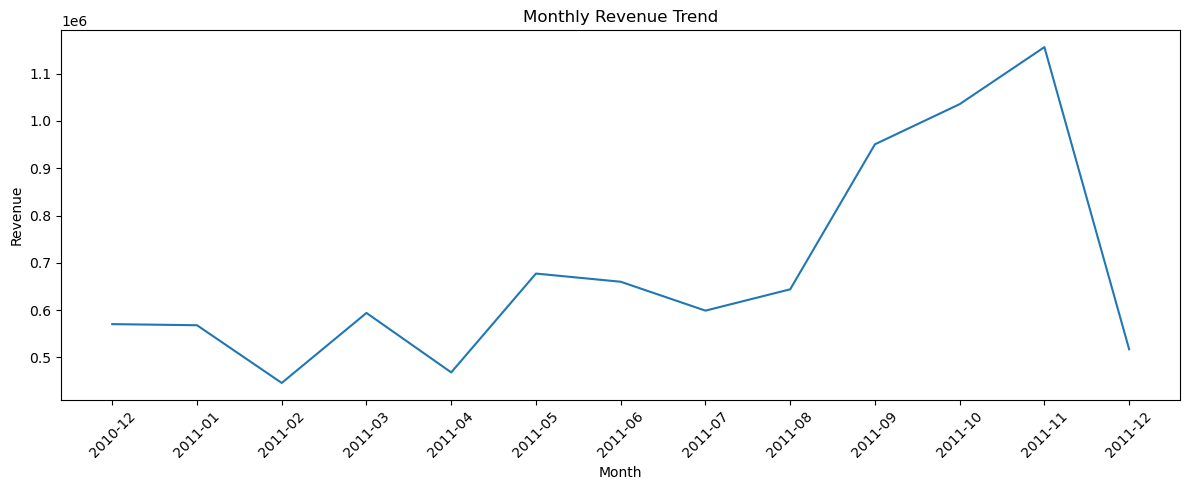

In [25]:
plt.figure(figsize=(12,5))

plt.plot(monthly_revenue.index, monthly_revenue.values)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()
#This is the first important EDA chart. From the cleaned data, the highest monthly revenue is in November 2011, at approximately £1.16 million.

In [19]:
top_products = (
    df.groupby("Description")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: TotalAmount, dtype: float64

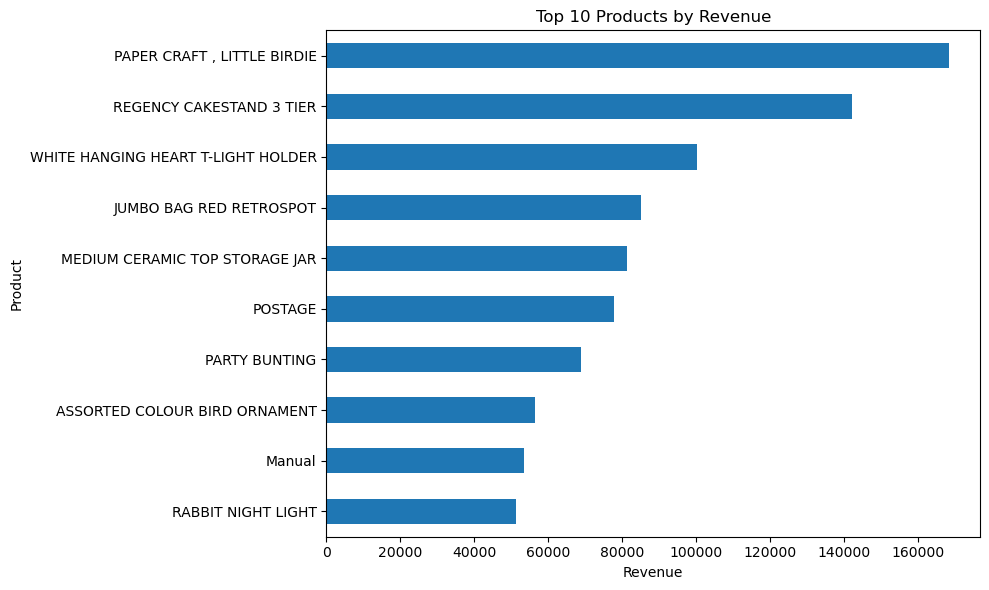

In [20]:
plt.figure(figsize=(10,6))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [21]:
top_countries = (
    df.groupby("Country")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_countries

Country
United Kingdom    7285024.64
Netherlands        285446.34
EIRE               265262.46
Germany            228678.40
France             208934.31
Australia          138453.81
Spain               61558.56
Switzerland         56443.95
Belgium             41196.34
Sweden              38367.83
Name: TotalAmount, dtype: float64

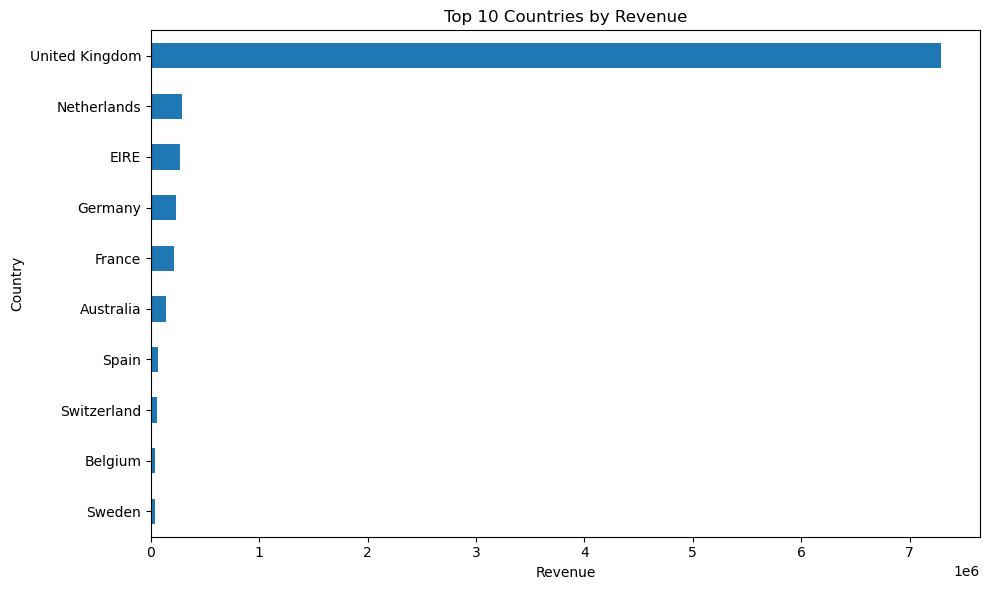

In [22]:
plt.figure(figsize=(10,6))

top_countries.sort_values().plot(kind="barh")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Country")

plt.tight_layout()
plt.show()

In [23]:
order_values = (
    df.groupby("InvoiceNo")["TotalAmount"]
    .sum()
    .sort_values(ascending=False)
)

order_values.head(10)

InvoiceNo
581483    168469.60
541431     77183.60
556444     38970.00
567423     31698.16
556917     22775.93
572209     22206.00
567381     22104.80
563614     21880.44
550461     21535.90
572035     20277.92
Name: TotalAmount, dtype: float64